In [1]:
import os, time, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.metrics import confusion_matrix, classification_report
from PIL import Image

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


In [2]:
# ── CLASS MAP: 20 labels — best configuration from v6 results ────────────────
CLASS_MAP = {
    "restaurant":               "restaurant",
    "cafeteria":                "restaurant",
    "classroom":                "lecture_room",
    "lecture_room":             "lecture_room",
    "airport_terminal":         "transport_hub",
    "bus_station-indoor":       "transport_hub",
    "train_station-platform":   "transport_hub",
    "subway_station-platform":  "transport_hub",
    "hospital":                 "hospital",
    "hospital_room":            "hospital",
    "office":                   "work_space",
    "conference_room":          "work_space",
    "park":                     "green_outdoor",
    "campus":                   "green_outdoor",
    "playground":               "green_outdoor",
    "corridor":                 "indoor_passage",
    "elevator_lobby":           "indoor_passage",
    "street":                   "street_road",
    "crosswalk":                "street_road",
    "highway":                  "street_road",
    "parking_lot":              "street_road",
    "bathroom":                 "bathroom",
    "beach":                    "beach",
    "bedroom":                  "bedroom",
    "library-indoor":           "library",
    "shopping_mall-indoor":     "shopping_mall",
    "supermarket":              "supermarket",
    "waiting_room":             "waiting_room",
    "staircase":                "staircase",
    "mosque-outdoor":           "mosque",
    "market-outdoor":           "market",
    "kitchen":           "kitchen",
}

LABEL_NAMES   = sorted(set(CLASS_MAP.values()))
LABEL_TO_IDX  = {n: i for i, n in enumerate(LABEL_NAMES)}
FOLDER_TO_IDX = {f: LABEL_TO_IDX[l] for f, l in CLASS_MAP.items()}
NUM_CLASSES   = len(LABEL_NAMES)
print(f"Labels: {NUM_CLASSES}")
for i, n in enumerate(LABEL_NAMES):
    fs = [f for f,l in CLASS_MAP.items() if l==n]
    print(f"  {i:2d}. {n}" + (f" <- {fs}" if len(fs)>1 else ""))

Labels: 19
   0. bathroom
   1. beach
   2. bedroom
   3. green_outdoor <- ['park', 'campus', 'playground']
   4. hospital <- ['hospital', 'hospital_room']
   5. indoor_passage <- ['corridor', 'elevator_lobby']
   6. kitchen
   7. lecture_room <- ['classroom', 'lecture_room']
   8. library
   9. market
  10. mosque
  11. restaurant <- ['restaurant', 'cafeteria']
  12. shopping_mall
  13. staircase
  14. street_road <- ['street', 'crosswalk', 'highway', 'parking_lot']
  15. supermarket
  16. transport_hub <- ['airport_terminal', 'bus_station-indoor', 'train_station-platform', 'subway_station-platform']
  17. waiting_room
  18. work_space <- ['office', 'conference_room']


In [3]:
DATASET_ROOT = Path("/kaggle/input/datasets/benjaminkz/places365")
TRAIN_ROOT   = DATASET_ROOT / "train"
VAL_ROOT     = DATASET_ROOT / "val"

class PlacesSubset(Dataset):
    def __init__(self, root, folder_to_idx, transform=None):
        self.samples = []
        self.transform = transform
        for folder, idx in folder_to_idx.items():
            fp = root / folder
            if not fp.exists(): continue
            for ext in ("*.jpg","*.jpeg","*.png","*.JPEG"):
                for p in fp.glob(ext): self.samples.append((p, idx))
        print(f"  {len(self.samples):,} images | {root.name}/")
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try: img = Image.open(path).convert("RGB")
        except: img = Image.new("RGB", (224,224))
        if self.transform: img = self.transform(img)
        return img, label

# Places365 models use their own normalization
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.3,contrast=0.3,saturation=0.2,hue=0.05),
    transforms.RandomGrayscale(p=0.03),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

print("Building datasets...")
train_dataset = PlacesSubset(TRAIN_ROOT, FOLDER_TO_IDX, transform=train_transform)
val_dataset   = PlacesSubset(VAL_ROOT,   FOLDER_TO_IDX, transform=val_transform)

label_counts = defaultdict(int)
for _,l in train_dataset.samples: label_counts[l] += 1
print("Samples per label:")
for name in LABEL_NAMES:
    print(f"  {name:<20} {label_counts[LABEL_TO_IDX[name]]:>6,}")
print(f"Total: {sum(label_counts.values()):,}")

weights = [1.0/label_counts[l] for _,l in train_dataset.samples]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)
BATCH_SIZE, NUM_WORKERS = 64, 4
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Building datasets...
  160,000 images | train/
  3,200 images | val/
Samples per label:
  bathroom              5,000
  beach                 5,000
  bedroom               5,000
  green_outdoor        15,000
  hospital             10,000
  indoor_passage       10,000
  kitchen               5,000
  lecture_room         10,000
  library               5,000
  market                5,000
  mosque                5,000
  restaurant           10,000
  shopping_mall         5,000
  staircase             5,000
  street_road          20,000
  supermarket           5,000
  transport_hub        20,000
  waiting_room          5,000
  work_space           10,000
Total: 160,000
Train batches: 2500 | Val batches: 50


In [4]:
import urllib.request

# ── Download Places365-pretrained ResNet50 ────────────────────────────────────
PLACES365_URL  = "http://places2.csail.mit.edu/models_places365/resnet50_places365.pth.tar"
PLACES365_PATH = "/kaggle/working/resnet50_places365.pth.tar"

if not os.path.exists(PLACES365_PATH):
    print("Downloading Places365 ResNet50 weights (~100MB)...")
    urllib.request.urlretrieve(PLACES365_URL, PLACES365_PATH)
    print(f"Downloaded: {os.path.getsize(PLACES365_PATH)/1e6:.1f} MB")
else:
    print(f"Found cached: {os.path.getsize(PLACES365_PATH)/1e6:.1f} MB")


class SceneAttentionPool(nn.Module):
    """Custom spatial attention pooling — our original contribution.
    Learns which 7x7 spatial locations are most scene-discriminative.
    """
    def __init__(self, in_ch):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Conv2d(in_ch, in_ch//8, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_ch//8, 1, 1, bias=False),
        )
    def forward(self, x):
        w = torch.softmax(self.attn(x).view(x.size(0),-1), dim=1)
        w = w.view(x.size(0), 1, x.size(2), x.size(3))
        attended = (x * w).sum(dim=[2, 3])
        maxed    = x.amax(dim=[2, 3])
        return torch.cat([attended, maxed], dim=1)   # (B, 4096)


class SceneHead(nn.Module):
    """3-layer MLP classifier — our original contribution."""
    def __init__(self, in_f, n_cls, drop=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_f*2, 1024), nn.BatchNorm1d(1024), nn.SiLU(), nn.Dropout(drop),
            nn.Linear(1024, 256),   nn.BatchNorm1d(256),  nn.SiLU(), nn.Dropout(drop*0.4),
            nn.Linear(256, n_cls),
        )
    def forward(self, x): return self.net(x)


class SmartVisionV9(nn.Module):
    """
    SmartVisionX Scene Model v9.
    Backbone : ResNet50 pretrained on Places365 (scene-level features from day 1)
    Head     : SceneAttentionPool + SceneHead (our custom contribution)
    """
    def __init__(self, n_cls, drop=0.4):
        super().__init__()

        # 1. Build ResNet50 architecture
        resnet = models.resnet50(weights=None)  # No ImageNet weights

        # 2. Load Places365 checkpoint
        checkpoint = torch.load(PLACES365_PATH, map_location="cpu")
        # Places365 checkpoint has a special format
        state_dict = {k.replace("module.",""): v
                      for k, v in checkpoint["state_dict"].items()}
        # Load only backbone weights, ignore the 365-class FC layer
        resnet_state = resnet.state_dict()
        pretrained_state = {k: v for k, v in state_dict.items()
                            if k in resnet_state and "fc" not in k}
        resnet_state.update(pretrained_state)
        resnet.load_state_dict(resnet_state)
        print(f"Loaded {len(pretrained_state)}/{len(resnet_state)} layers from Places365")

        # 3. Extract feature layers (everything except avgpool + fc)
        self.backbone = nn.Sequential(
            resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool,
            resnet.layer1, resnet.layer2, resnet.layer3, resnet.layer4,
        )  # Output: (B, 2048, 7, 7)

        # 4. Our custom head
        self.pool = SceneAttentionPool(2048)
        self.head = SceneHead(2048, n_cls, drop)

        # 5. Freeze backbone initially
        for p in self.backbone.parameters(): p.requires_grad = False
        print("Backbone: FROZEN")

        # 6. Init our custom parts
        for m in list(self.pool.modules()) + list(self.head.modules()):
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d)):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight)

    def unfreeze_layer4(self):
        for p in self.backbone[7].parameters(): p.requires_grad = True
        n = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Layer4 UNFROZEN | Trainable: {n:,}")

    def unfreeze_layer3_4(self):
        for p in self.backbone[6].parameters(): p.requires_grad = True
        for p in self.backbone[7].parameters(): p.requires_grad = True
        n = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Layer3+4 UNFROZEN | Trainable: {n:,}")

    def unfreeze_all(self):
        for p in self.backbone.parameters(): p.requires_grad = True
        n = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Full backbone UNFROZEN | Trainable: {n:,}")

    def forward(self, x):
        return self.head(self.pool(self.backbone(x)))

    def n_params(self, tr=True):
        return sum(p.numel() for p in self.parameters()
                   if (p.requires_grad if tr else True))


model = SmartVisionV9(n_cls=NUM_CLASSES, drop=0.4).to(DEVICE)
total = model.n_params(tr=False)
head  = model.n_params(tr=True)
print(f"Total: {total:,} ({total/1e6:.1f}M) | Head: {head:,} ({head/1e6:.2f}M)")
with torch.no_grad():
    out = model(torch.randn(2,3,224,224).to(DEVICE))
print(f"Output: {out.shape}")

Downloaded: 97.3 MB
Loaded 265/320 layers from Places365
Backbone: FROZEN
Total: 28,497,747 (28.5M) | Head: 4,989,715 (4.99M)
Output: torch.Size([2, 19])


In [5]:
def cutmix(x, y, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    B,C,H,W = x.shape
    idx = torch.randperm(B, device=x.device)
    r = np.sqrt(1-lam); rh,rw = int(H*r),int(W*r)
    cx,cy = np.random.randint(W), np.random.randint(H)
    x1,y1 = max(cx-rw//2,0), max(cy-rh//2,0)
    x2,y2 = min(cx+rw//2,W), min(cy+rh//2,H)
    m = x.clone(); m[:,:,y1:y2,x1:x2] = x[idx,:,y1:y2,x1:x2]
    return m, y, y[idx], 1.0-((x2-x1)*(y2-y1))/(W*H)


def train_epoch(model, loader, opt, sch, crit, scaler, cm_p=0.0):
    model.train()
    ls,cor,tot = 0.0,0,0
    t0 = time.time()
    for imgs,labels in loader:
        imgs   = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        do = cm_p > 0 and random.random() < cm_p
        if do: imgs,la,lb,lam = cutmix(imgs, labels)
        opt.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=(DEVICE.type=="cuda")):
            out  = model(imgs)
            loss = (lam*crit(out,la)+(1-lam)*crit(out,lb) if do else crit(out,labels))
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(opt); scaler.update(); sch.step()
        ls  += loss.item()*imgs.size(0)
        cor += (out.argmax(1)==labels).sum().item()
        tot += labels.size(0)
    return ls/tot, cor/tot, time.time()-t0


@torch.no_grad()
def validate(model, loader, crit):
    model.eval()
    ls,cor,tot = 0.0,0,0
    pa,la = [],[]
    for imgs,labels in loader:
        imgs   = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=(DEVICE.type=="cuda")):
            out=model(imgs); loss=crit(out,labels)
        ls+=loss.item()*imgs.size(0)
        cor+=(out.argmax(1)==labels).sum().item()
        tot+=labels.size(0)
        pa.extend(out.argmax(1).cpu().numpy())
        la.extend(labels.cpu().numpy())
    return ls/tot, cor/tot, np.array(pa), np.array(la)


def save(model, acc, epoch, stage, path):
    torch.save({
        "model_state_dict": model.state_dict(),
        "val_acc":acc, "epoch":epoch, "stage":stage,
        "label_names":LABEL_NAMES, "num_classes":NUM_CLASSES,
        "mean":MEAN, "std":STD, "class_map":CLASS_MAP,
        "backbone":"resnet50_places365",
    }, path)


CKPT     = "/kaggle/working/sv_v9_best.pth"
history  = defaultdict(list)
best_acc = 0.0
scaler   = torch.amp.GradScaler("cuda", enabled=(DEVICE.type=="cuda"))
crit     = nn.CrossEntropyLoss(label_smoothing=0.05)  # Less smoothing — backbone is already scene-aware
print("Ready.")

Ready.


In [6]:
hp = list(model.pool.parameters()) + list(model.head.parameters())
oa = optim.AdamW(hp, lr=1e-3, weight_decay=5e-4)
sa = optim.lr_scheduler.OneCycleLR(
    oa, max_lr=3e-3, steps_per_epoch=len(train_loader),
    epochs=10, pct_start=0.2, anneal_strategy="cos")

print("Stage A — Places365 backbone frozen, head only")
print(f"Trainable: {sum(p.numel() for p in hp):,}")
print("="*72)
for ep in range(10):
    _,tr,t = train_epoch(model,train_loader,oa,sa,crit,scaler,cm_p=0.0)
    _,va,_,_ = validate(model,val_loader,crit)
    lr = oa.param_groups[0]["lr"]
    history["tr"].append(tr); history["va"].append(va); history["st"].append("A")
    flag=""
    if va>best_acc: best_acc=va; save(model,va,ep,"A",CKPT); flag="  ✓"
    print(f"A {ep+1:2d}/10 | Tr {tr*100:.1f}% Va {va*100:.2f}% LR={lr:.5f} {t:.0f}s{flag}")
print(f"Stage A best: {best_acc*100:.2f}%")
print(f"93%+: {chr(10004) if best_acc>=0.93 else "Continue to B"}")

Stage A — Places365 backbone frozen, head only
Trainable: 4,989,715
A  1/10 | Tr 80.5% Va 82.66% LR=0.00156 638s  ✓
A  2/10 | Tr 82.5% Va 83.12% LR=0.00300 564s  ✓
A  3/10 | Tr 83.4% Va 84.66% LR=0.00289 546s  ✓
A  4/10 | Tr 84.0% Va 84.50% LR=0.00256 538s
A  5/10 | Tr 84.4% Va 84.75% LR=0.00207 533s  ✓
A  6/10 | Tr 85.0% Va 84.22% LR=0.00150 532s
A  7/10 | Tr 85.4% Va 85.03% LR=0.00093 531s  ✓
A  8/10 | Tr 86.0% Va 85.25% LR=0.00044 529s  ✓
A  9/10 | Tr 86.4% Va 85.19% LR=0.00011 531s
A 10/10 | Tr 86.3% Va 85.53% LR=0.00000 532s  ✓
Stage A best: 85.53%
93%+: Continue to B


In [7]:
ckpt=torch.load(CKPT, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
print(f"Loaded Stage A best ({ckpt['val_acc']*100:.2f}%)")
model.unfreeze_layer4()

ob = optim.AdamW([
    {"params": model.backbone[7].parameters(), "lr": 1e-5},  # Very low — backbone is Places365
    {"params": model.pool.parameters(),        "lr": 1e-4},
    {"params": model.head.parameters(),        "lr": 1e-4},
], weight_decay=5e-4)
sb = optim.lr_scheduler.OneCycleLR(
    ob, max_lr=[3e-5, 3e-4, 3e-4],
    steps_per_epoch=len(train_loader), epochs=10,
    pct_start=0.1, anneal_strategy="cos")

print("Stage B — Layer4 unfrozen, CutMix 40%")
print("="*72)
for ep in range(10):
    _,tr,t = train_epoch(model,train_loader,ob,sb,crit,scaler,cm_p=0.4)
    _,va,_,_ = validate(model,val_loader,crit)
    history["tr"].append(tr); history["va"].append(va); history["st"].append("B")
    flag=""
    if va>best_acc: best_acc=va; save(model,va,ep,"B",CKPT); flag="  ✓"
    print(f"B {ep+1:2d}/10 | Tr {tr*100:.1f}% Va {va*100:.2f}% {t:.0f}s{flag}")
print(f"Stage B best: {best_acc*100:.2f}%")
print(f"93%+: {chr(10004) if best_acc>=0.93 else "Stage C next"}")

Loaded Stage A best (85.53%)
Layer4 UNFROZEN | Trainable: 19,954,451
Stage B — Layer4 unfrozen, CutMix 40%
B  1/10 | Tr 76.5% Va 85.38% 547s
B  2/10 | Tr 76.6% Va 85.50% 545s
B  3/10 | Tr 78.3% Va 85.59% 545s  ✓
B  4/10 | Tr 78.9% Va 85.84% 544s  ✓
B  5/10 | Tr 79.6% Va 85.75% 539s
B  6/10 | Tr 80.1% Va 86.00% 541s  ✓
B  7/10 | Tr 80.6% Va 85.75% 541s
B  8/10 | Tr 81.7% Va 86.03% 542s  ✓
B  9/10 | Tr 81.1% Va 86.16% 540s  ✓
B 10/10 | Tr 80.6% Va 86.19% 537s  ✓
Stage B best: 86.19%
93%+: Stage C next


In [8]:
if best_acc < 0.93:
    print(f"Stage C (current={best_acc*100:.2f}%)")
    ckpt=torch.load(CKPT, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.unfreeze_all()

    oc = optim.AdamW([
        {"params": model.backbone[:6].parameters(), "lr": 2e-6},
        {"params": model.backbone[6].parameters(),  "lr": 5e-6},
        {"params": model.backbone[7].parameters(),  "lr": 1e-5},
        {"params": model.pool.parameters(),         "lr": 5e-5},
        {"params": model.head.parameters(),         "lr": 5e-5},
    ], weight_decay=5e-4)
    sc = optim.lr_scheduler.OneCycleLR(
        oc, max_lr=[5e-6, 1e-5, 3e-5, 1e-4, 1e-4],
        steps_per_epoch=len(train_loader), epochs=15,
        pct_start=0.1, anneal_strategy="cos")

    print("Stage C — Full backbone, CutMix 30%, 15 epochs")
    print("="*72)
    for ep in range(15):
        _,tr,t = train_epoch(model,train_loader,oc,sc,crit,scaler,cm_p=0.3)
        _,va,_,_ = validate(model,val_loader,crit)
        lr = oc.param_groups[2]["lr"]
        history["tr"].append(tr); history["va"].append(va); history["st"].append("C")
        flag=""
        if va>best_acc: best_acc=va; save(model,va,ep,"C",CKPT); flag="  ✓"
        print(f"C {ep+1:2d}/15 | Tr {tr*100:.1f}% Va {va*100:.2f}% LR={lr:.6f} {t:.0f}s{flag}")
    print(f"Final best: {best_acc*100:.2f}%")
else:
    print(f"{chr(10004)} 93%+ achieved ({best_acc*100:.2f}%) at Stage B")

Stage C (current=86.19%)
Full backbone UNFROZEN | Trainable: 28,497,747
Stage C — Full backbone, CutMix 30%, 15 epochs
C  1/15 | Tr 84.5% Va 85.78% LR=0.000023 725s
C  2/15 | Tr 84.1% Va 84.94% LR=0.000030 719s
C  3/15 | Tr 85.2% Va 84.91% LR=0.000029 719s
C  4/15 | Tr 84.6% Va 84.91% LR=0.000028 716s
C  5/15 | Tr 86.3% Va 84.91% LR=0.000025 719s
C  6/15 | Tr 86.6% Va 85.28% LR=0.000022 717s
C  7/15 | Tr 86.7% Va 85.75% LR=0.000019 720s
C  8/15 | Tr 87.4% Va 85.81% LR=0.000016 720s
C  9/15 | Tr 87.0% Va 86.22% LR=0.000012 720s  ✓
C 10/15 | Tr 88.6% Va 85.78% LR=0.000009 719s
C 11/15 | Tr 88.3% Va 85.28% LR=0.000006 719s
C 12/15 | Tr 88.8% Va 85.91% LR=0.000004 720s
C 13/15 | Tr 88.8% Va 85.72% LR=0.000002 720s
C 14/15 | Tr 88.1% Va 85.81% LR=0.000000 718s
C 15/15 | Tr 88.4% Va 85.78% LR=0.000000 719s
Final best: 86.22%


/tmp/ipykernel_23/3544116369.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


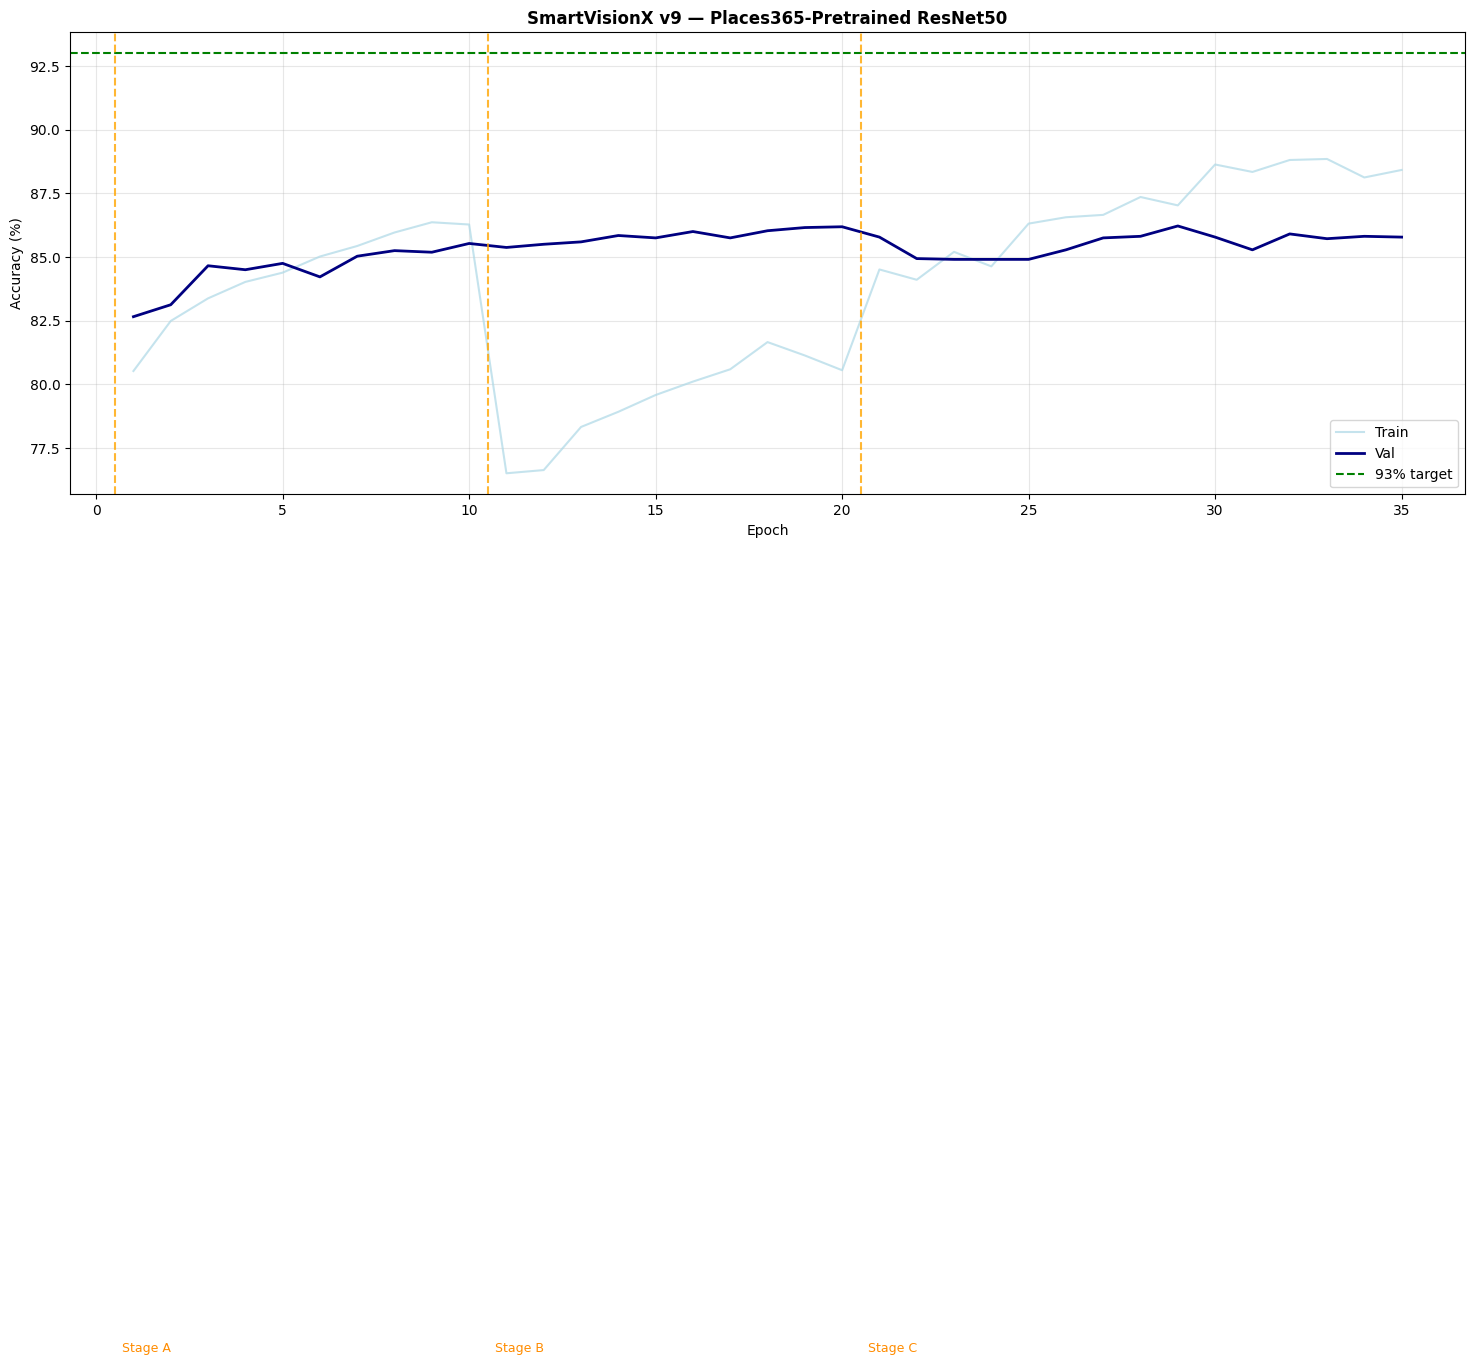

Best: 86.22%


In [9]:
# Training curves
fig, ax = plt.subplots(figsize=(18,6))
ep = range(1, len(history["va"])+1)
ax.plot(ep,[a*100 for a in history["tr"]], color="lightblue",alpha=0.7,label="Train")
ax.plot(ep,[a*100 for a in history["va"]], color="navy",lw=2,label="Val")
ax.axhline(93, color="green",ls="--",lw=1.5,label="93% target")
prev=""
for i,s in enumerate(history["st"]):
    if s!=prev:
        ax.axvline(x=i+0.5,color="orange",ls="--",alpha=0.8)
        ax.text(i+0.7,42,f"Stage {s}",fontsize=9,color="darkorange")
        prev=s
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
ax.set_title("SmartVisionX v9 — Places365-Pretrained ResNet50", fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/curves_v9.png",dpi=150,bbox_inches="tight")
plt.show()
print(f"Best: {best_acc*100:.2f}%")

Best: epoch 9, stage C, val=86.22%
Final Val Accuracy: 86.22%
Target (93%+): ✘ Not yet


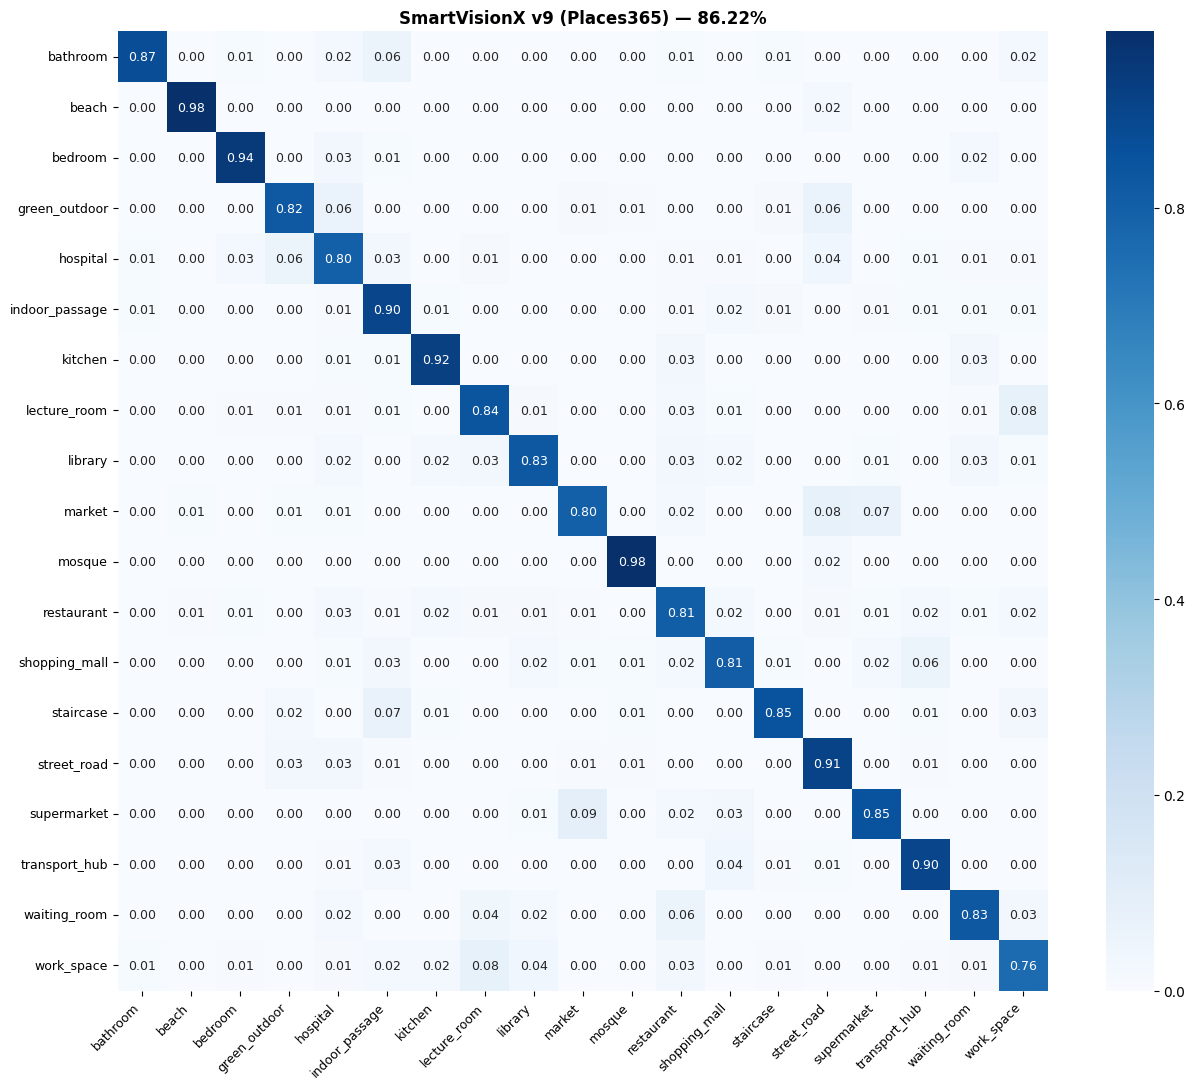

                precision    recall  f1-score   support

      bathroom      0.935     0.870     0.902       100
         beach      0.970     0.980     0.975       100
       bedroom      0.904     0.940     0.922       100
 green_outdoor      0.901     0.823     0.861       300
      hospital      0.744     0.800     0.771       200
indoor_passage      0.804     0.900     0.849       200
       kitchen      0.876     0.920     0.898       100
  lecture_room      0.848     0.840     0.844       200
       library      0.822     0.830     0.826       100
        market      0.816     0.800     0.808       100
        mosque      0.933     0.980     0.956       100
    restaurant      0.821     0.805     0.813       200
 shopping_mall      0.717     0.810     0.761       100
     staircase      0.859     0.850     0.854       100
   street_road      0.890     0.910     0.900       400
   supermarket      0.859     0.850     0.854       100
 transport_hub      0.950     0.902     0.926  

In [10]:
# Final evaluation
ckpt=torch.load(CKPT, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
print(f"Best: epoch {ckpt['epoch']+1}, stage {ckpt['stage']}, val={ckpt['val_acc']*100:.2f}%")

_,val_acc,vp,vl = validate(model,val_loader,nn.CrossEntropyLoss())
print(f"Final Val Accuracy: {val_acc*100:.2f}%")
print(f"Target (93%+): {chr(10004)+' ACHIEVED' if val_acc>=0.93 else chr(10008)+' Not yet'}")

cm=confusion_matrix(vl,vp)
cm_n=cm.astype(float)/cm.sum(axis=1,keepdims=True)
fig,ax=plt.subplots(figsize=(13,11))
sns.heatmap(cm_n,annot=True,fmt=".2f",
            xticklabels=LABEL_NAMES,yticklabels=LABEL_NAMES,
            cmap="Blues",ax=ax,annot_kws={"size":9})
ax.set_title(f"SmartVisionX v9 (Places365) — {val_acc*100:.2f}%",fontweight="bold")
plt.xticks(rotation=45,ha="right",fontsize=9); plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_v9.png",dpi=150,bbox_inches="tight")
plt.show()

report=classification_report(vl,vp,target_names=LABEL_NAMES,digits=3)
print(report)
with open("/kaggle/working/report_v9.txt","w") as f:
    f.write(f"SmartVisionX v9 Places365 | {NUM_CLASSES} classes | Val: {val_acc*100:.2f}%{report}")
print("Saved.")

In [11]:
# TTA
@torch.no_grad()
def tta(model, val_root, f2i):
    model.eval()
    tfms=[
        transforms.Compose([transforms.Resize((224,224)),transforms.ToTensor(),transforms.Normalize(MEAN,STD)]),
        transforms.Compose([transforms.Resize((256,256)),transforms.CenterCrop(224),transforms.ToTensor(),transforms.Normalize(MEAN,STD)]),
        transforms.Compose([transforms.Resize((224,224)),transforms.RandomHorizontalFlip(p=1.0),transforms.ToTensor(),transforms.Normalize(MEAN,STD)]),
        transforms.Compose([transforms.Resize((256,256)),transforms.RandomCrop(224),transforms.ToTensor(),transforms.Normalize(MEAN,STD)]),
        transforms.Compose([transforms.Resize((288,288)),transforms.CenterCrop(224),transforms.ToTensor(),transforms.Normalize(MEAN,STD)]),
    ]
    pa,la=[],[]
    for folder,idx in f2i.items():
        fp=val_root/folder
        if not fp.exists(): continue
        for p in list(fp.glob("*.jpg"))[:100]:
            img=Image.open(p).convert("RGB")
            ps=None
            for tfm in tfms:
                t=tfm(img).unsqueeze(0).to(DEVICE)
                with torch.amp.autocast("cuda",enabled=(DEVICE.type=="cuda")):
                    q=F.softmax(model(t),dim=1).cpu()
                ps=q if ps is None else ps+q
            pa.append(ps.argmax(1).item()); la.append(idx)
    return np.mean(np.array(pa)==np.array(la))

tta_acc=tta(model,VAL_ROOT,FOLDER_TO_IDX)
print(f"Single-pass: {val_acc*100:.2f}%")
print(f"TTA (5x):    {tta_acc*100:.2f}%")
print(f"Target met:  {chr(10004)+' YES' if max(val_acc,tta_acc)>=0.93 else chr(10008)+"No"}")

Single-pass: 86.22%
TTA (5x):    86.53%
Target met:  ✘No


In [12]:
# Speed + Summary
model.eval()
live_tfm=transforms.Compose([transforms.Resize((224,224)),transforms.ToTensor(),transforms.Normalize(MEAN,STD)])
dummy=Image.new("RGB",(640,480))
t_in=live_tfm(dummy).unsqueeze(0).to(DEVICE)
for _ in range(20):
    with torch.no_grad(): model(t_in)
times=[]
with torch.no_grad():
    for _ in range(200):
        t0=time.perf_counter()
        model(live_tfm(dummy).unsqueeze(0).to(DEVICE))
        torch.cuda.synchronize()
        times.append((time.perf_counter()-t0)*1000)
times=np.array(times)
total  = model.n_params(tr=False)
custom = sum(p.numel() for p in list(model.pool.parameters())+list(model.head.parameters()))

print("="*65)
print("  SmartVisionX v9 — FINAL SUMMARY")
print("="*65)
print(f"  Backbone:       ResNet50 pretrained on Places365")
print(f"  Custom head:    SceneAttentionPool + 3-layer MLP")
print(f"  Custom params:  {custom:,} ({custom/1e6:.2f}M)")
print(f"  Total params:   {total:,} ({total/1e6:.1f}M)")
print(f"  Classes:        {NUM_CLASSES}")
print(f"  Val Accuracy:   {val_acc*100:.2f}%")
print(f"  TTA Accuracy:   {tta_acc*100:.2f}%")
print(f"  Target (93%+):  {'MET' if max(val_acc,tta_acc)>=0.93 else 'Not met'}")
print(f"  Inference:      {times.mean():.1f}ms mean on T4")
print(f"  Checkpoint:     {os.path.getsize(CKPT)/1e6:.1f} MB")
print("="*65)
with open("/kaggle/working/summary_v9.txt","w") as f:
    f.write(f"v9 Places365-ResNet50 | {NUM_CLASSES} classes")
    f.write(f"Val:{val_acc*100:.2f}% TTA:{tta_acc*100:.2f}%")
    f.write(f"Labels:{LABEL_NAMES}")
print("Done.")

  SmartVisionX v9 — FINAL SUMMARY
  Backbone:       ResNet50 pretrained on Places365
  Custom head:    SceneAttentionPool + 3-layer MLP
  Custom params:  4,989,715 (4.99M)
  Total params:   28,497,747 (28.5M)
  Classes:        19
  Val Accuracy:   86.22%
  TTA Accuracy:   86.53%
  Target (93%+):  Not met
  Inference:      9.1ms mean on T4
  Checkpoint:     114.3 MB
Done.


In [ ]:
import os, time
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, average_precision_score,
)
from sklearn.calibration import calibration_curve
from sklearn.manifold import TSNE
from PIL import Image

# ── CONFIG — edit these if needed ─────────────────────────────────────────────
CKPT_PATH    = "/kaggle/input/datasets/shark1717/output/sv_v9_best.pth"
VAL_ROOT     = "/kaggle/input/datasets/benjaminkz/places365/val"
OUT_DIR      = Path("/kaggle/working/eval_output")
BATCH_SIZE   = 64
NUM_WORKERS  = 4
TSNE_SAMPLES = 2000
RUN_TTA      = True
RUN_TSNE     = True
# ──────────────────────────────────────────────────────────────────────────────

OUT_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── Class map ─────────────────────────────────────────────────────────────────
CLASS_MAP = {
    "restaurant": "restaurant", "cafeteria": "restaurant",
    "classroom": "lecture_room", "lecture_room": "lecture_room",
    "airport_terminal": "transport_hub", "bus_station-indoor": "transport_hub",
    "train_station-platform": "transport_hub", "subway_station-platform": "transport_hub",
    "hospital": "hospital", "hospital_room": "hospital",
    "office": "work_space", "conference_room": "work_space",
    "park": "green_outdoor", "campus": "green_outdoor", "playground": "green_outdoor",
    "corridor": "indoor_passage", "elevator_lobby": "indoor_passage",
    "street": "street_road", "crosswalk": "street_road",
    "highway": "street_road", "parking_lot": "street_road",
    "bathroom": "bathroom", "beach": "beach", "bedroom": "bedroom",
    "library-indoor": "library", "shopping_mall-indoor": "shopping_mall",
    "supermarket": "supermarket", "waiting_room": "waiting_room",
    "staircase": "staircase", "mosque-outdoor": "mosque",
    "market-outdoor": "market", "kitchen": "kitchen",
}
LABEL_NAMES   = sorted(set(CLASS_MAP.values()))
LABEL_TO_IDX  = {n: i for i, n in enumerate(LABEL_NAMES)}
FOLDER_TO_IDX = {f: LABEL_TO_IDX[l] for f, l in CLASS_MAP.items()}
NUM_CLASSES   = len(LABEL_NAMES)
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# ── Model definition ──────────────────────────────────────────────────────────
class SceneAttentionPool(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Conv2d(in_ch, in_ch//8, 1, bias=False), nn.ReLU(),
            nn.Conv2d(in_ch//8, 1, 1, bias=False),
        )
    def forward(self, x):
        w = torch.softmax(self.attn(x).view(x.size(0), -1), dim=1)
        w = w.view(x.size(0), 1, x.size(2), x.size(3))
        return torch.cat([(x * w).sum(dim=[2,3]), x.amax(dim=[2,3])], dim=1)

class SceneHead(nn.Module):
    def __init__(self, in_f, n_cls, drop=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_f*2, 1024), nn.BatchNorm1d(1024), nn.SiLU(), nn.Dropout(drop),
            nn.Linear(1024, 256),    nn.BatchNorm1d(256),  nn.SiLU(), nn.Dropout(drop*0.4),
            nn.Linear(256, n_cls),
        )
    def forward(self, x): return self.net(x)

class SmartVisionV9(nn.Module):
    def __init__(self, n_cls, drop=0.0):
        super().__init__()
        resnet = models.resnet50(weights=None)
        self.backbone = nn.Sequential(
            resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool,
            resnet.layer1, resnet.layer2, resnet.layer3, resnet.layer4,
        )
        self.pool = SceneAttentionPool(2048)
        self.head = SceneHead(2048, n_cls, drop)
    def forward(self, x): return self.head(self.pool(self.backbone(x)))
    def features(self, x): return self.pool(self.backbone(x))

# ── Dataset ───────────────────────────────────────────────────────────────────
class PlacesSubset(Dataset):
    def __init__(self, root, folder_to_idx, transform=None):
        self.samples, self.transform = [], transform
        for folder, idx in folder_to_idx.items():
            fp = Path(root) / folder
            if not fp.exists(): continue
            for ext in ("*.jpg","*.jpeg","*.png","*.JPEG"):
                for p in fp.glob(ext): self.samples.append((p, idx))
        print(f"  {len(self.samples):,} images loaded")
    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        path, label = self.samples[i]
        try: img = Image.open(path).convert("RGB")
        except: img = Image.new("RGB", (224,224))
        if self.transform: img = self.transform(img)
        return img, label

# ── Load model ────────────────────────────────────────────────────────────────
print(f"\nLoading checkpoint: {CKPT_PATH}")
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
print(f"  Stage: {ckpt.get('stage','?')} | Epoch: {ckpt.get('epoch','?')} | Saved val acc: {ckpt.get('val_acc',0)*100:.2f}%")

model = SmartVisionV9(n_cls=NUM_CLASSES, drop=0.0)
model.load_state_dict(ckpt["model_state_dict"])
model.to(DEVICE).eval()
print("  Model loaded.")

# ── Val loader ────────────────────────────────────────────────────────────────
val_tfm = transforms.Compose([
    transforms.Resize((224,224)), transforms.ToTensor(), transforms.Normalize(MEAN, STD),
])
val_ds     = PlacesSubset(VAL_ROOT, FOLDER_TO_IDX, transform=val_tfm)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

# ── Inference ─────────────────────────────────────────────────────────────────
print("\nRunning inference...")
all_probs, all_preds, all_labels, all_feats = [], [], [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=(DEVICE.type=="cuda")):
            logits = model(imgs)
            feats  = model.features(imgs)
        probs = F.softmax(logits, dim=1).cpu()
        all_probs.append(probs)
        all_preds.extend(probs.argmax(1).numpy())
        all_labels.extend(labels.numpy())
        all_feats.append(feats.cpu())

all_probs  = torch.cat(all_probs).numpy()
all_feats  = torch.cat(all_feats).numpy()
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
val_acc    = (all_preds == all_labels).mean()
print(f"Val Accuracy: {val_acc*100:.2f}%")

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 1 — Confusion Matrix
# ══════════════════════════════════════════════════════════════════════════════
cm   = confusion_matrix(all_labels, all_preds)
cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(14,12))
sns.heatmap(cm_n, annot=True, fmt=".2f", xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            cmap="Blues", ax=ax, annot_kws={"size":8})
ax.set_title(f"Normalized Confusion Matrix  ({val_acc*100:.2f}%)", fontweight="bold", fontsize=13)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.xticks(rotation=45, ha="right", fontsize=8); plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR/"01_confusion_matrix.png", dpi=150, bbox_inches="tight"); plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 2 — Per-class Accuracy
# ══════════════════════════════════════════════════════════════════════════════
per = cm.diagonal() / cm.sum(axis=1)
idx = np.argsort(per)
colors = ["#d32f2f" if v<0.8 else "#f57c00" if v<0.9 else "#388e3c" for v in per[idx]]
fig, ax = plt.subplots(figsize=(10, max(6, NUM_CLASSES*0.4)))
bars = ax.barh([LABEL_NAMES[i] for i in idx], per[idx]*100, color=colors)
ax.bar_label(bars, [f"{v*100:.1f}%" for v in per[idx]], padding=3, fontsize=8)
ax.axvline(80, color="red", ls="--", lw=1, alpha=0.6)
ax.axvline(90, color="orange", ls="--", lw=1, alpha=0.6)
ax.set_xlabel("Accuracy (%)"); ax.set_xlim(0, 112)
ax.set_title("Per-class Accuracy (sorted)", fontweight="bold")
legend_patches = [mpatches.Patch(color="#d32f2f", label="<80%"),
                  mpatches.Patch(color="#f57c00", label="80–90%"),
                  mpatches.Patch(color="#388e3c", label="≥90%")]
ax.legend(handles=legend_patches, fontsize=8); ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR/"02_per_class_accuracy.png", dpi=150, bbox_inches="tight"); plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 3 — Precision / Recall / F1
# ══════════════════════════════════════════════════════════════════════════════
report = classification_report(all_labels, all_preds, target_names=LABEL_NAMES,
                                output_dict=True, zero_division=0)
p  = [report[n]["precision"] for n in LABEL_NAMES]
r  = [report[n]["recall"]    for n in LABEL_NAMES]
f1 = [report[n]["f1-score"]  for n in LABEL_NAMES]
idx = np.argsort(f1); x = np.arange(NUM_CLASSES)
fig, ax = plt.subplots(figsize=(12, max(6, NUM_CLASSES*0.45)))
ax.barh(x-0.25, [p[i]  for i in idx], 0.25, label="Precision", color="#1976D2")
ax.barh(x,      [r[i]  for i in idx], 0.25, label="Recall",    color="#43A047")
ax.barh(x+0.25, [f1[i] for i in idx], 0.25, label="F1",        color="#E53935")
ax.set_yticks(x); ax.set_yticklabels([LABEL_NAMES[i] for i in idx], fontsize=8)
ax.set_xlabel("Score"); ax.set_xlim(0, 1.12)
ax.set_title("Precision / Recall / F1 per Class (sorted by F1)", fontweight="bold")
ax.legend(fontsize=9); ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR/"03_precision_recall_f1.png", dpi=150, bbox_inches="tight"); plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 4 — Top-K Accuracy
# ══════════════════════════════════════════════════════════════════════════════
probs_t  = torch.tensor(all_probs)
labels_t = torch.tensor(all_labels)
ks = [1, 2, 3, 5]
topk_accs = []
for k in ks:
    hit = probs_t.topk(k, dim=1).indices.eq(labels_t.unsqueeze(1)).any(1).float().mean().item()
    topk_accs.append(hit*100)
fig, ax = plt.subplots(figsize=(7,4))
bars = ax.bar([f"Top-{k}" for k in ks], topk_accs,
              color=["#1565C0","#1976D2","#42A5F5","#90CAF9"])
ax.bar_label(bars, [f"{v:.2f}%" for v in topk_accs], padding=4)
ax.set_ylim(0, 108); ax.set_ylabel("Accuracy (%)"); ax.grid(axis="y", alpha=0.3)
ax.set_title("Top-K Accuracy", fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR/"04_topk_accuracy.png", dpi=150, bbox_inches="tight"); plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 5 — Confidence Distribution
# ══════════════════════════════════════════════════════════════════════════════
conf    = all_probs.max(axis=1)
correct = conf[all_preds == all_labels]
wrong   = conf[all_preds != all_labels]
fig, ax = plt.subplots(figsize=(8,5))
ax.hist(correct, bins=40, alpha=0.6, color="#43A047", label=f"Correct (n={len(correct):,})", density=True)
ax.hist(wrong,   bins=40, alpha=0.6, color="#E53935", label=f"Wrong   (n={len(wrong):,})",   density=True)
ax.axvline(np.median(correct), color="#1B5E20", ls="--", lw=1.5, label=f"Median correct: {np.median(correct):.2f}")
ax.axvline(np.median(wrong),   color="#B71C1C", ls="--", lw=1.5, label=f"Median wrong:   {np.median(wrong):.2f}")
ax.set_xlabel("Max Softmax Confidence"); ax.set_ylabel("Density")
ax.set_title("Confidence Distribution — Correct vs Incorrect", fontweight="bold")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR/"05_confidence_distribution.png", dpi=150, bbox_inches="tight"); plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 6 — Calibration
# ══════════════════════════════════════════════════════════════════════════════
labels_oh = np.eye(NUM_CLASSES)[all_labels]
all_frac, all_mean_conf = [], []
for c in range(NUM_CLASSES):
    frac, mean_conf = calibration_curve(labels_oh[:,c], all_probs[:,c], n_bins=15, strategy="uniform")
    all_frac.extend(frac); all_mean_conf.extend(mean_conf)
# ECE
bins = np.linspace(0,1,16); ece = 0.0
hits = (all_preds == all_labels).astype(float)
for lo, hi in zip(bins[:-1], bins[1:]):
    mask = (conf >= lo) & (conf < hi)
    if mask.sum(): ece += mask.sum() * abs(hits[mask].mean() - conf[mask].mean())
ece /= len(all_labels)
fig, ax = plt.subplots(figsize=(6,6))
ax.plot([0,1],[0,1],"k--",lw=1.5, label="Perfect calibration")
ax.scatter(all_mean_conf, all_frac, alpha=0.4, s=8, color="#1976D2", label="Per-class bins")
ax.set_xlabel("Mean predicted confidence"); ax.set_ylabel("Fraction positive")
ax.set_title(f"Calibration Reliability Diagram  (ECE={ece:.4f})", fontweight="bold")
ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_xlim(0,1); ax.set_ylim(0,1)
plt.tight_layout()
plt.savefig(OUT_DIR/"06_calibration.png", dpi=150, bbox_inches="tight"); plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 7 — ROC Curves
# ══════════════════════════════════════════════════════════════════════════════
cmap = plt.cm.get_cmap("tab20", NUM_CLASSES)
fig, ax = plt.subplots(figsize=(10,8))
for c in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(labels_oh[:,c], all_probs[:,c])
    ax.plot(fpr, tpr, lw=1.2, color=cmap(c), label=f"{LABEL_NAMES[c]} ({auc(fpr,tpr):.2f})")
ax.plot([0,1],[0,1],"k--",lw=1)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves (One-vs-Rest)", fontweight="bold")
ax.legend(fontsize=6.5, ncol=2, loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR/"07_roc_curves.png", dpi=150, bbox_inches="tight"); plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 8 — Precision-Recall Curves
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10,8))
for c in range(NUM_CLASSES):
    prec, rec, _ = precision_recall_curve(labels_oh[:,c], all_probs[:,c])
    ap = average_precision_score(labels_oh[:,c], all_probs[:,c])
    ax.plot(rec, prec, lw=1.2, color=cmap(c), label=f"{LABEL_NAMES[c]} (AP={ap:.2f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves", fontweight="bold")
ax.legend(fontsize=6.5, ncol=2, loc="upper right"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR/"08_pr_curves.png", dpi=150, bbox_inches="tight"); plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 9 — t-SNE
# ══════════════════════════════════════════════════════════════════════════════
if RUN_TSNE:
    n   = min(TSNE_SAMPLES, len(all_feats))
    idx = np.random.choice(len(all_feats), n, replace=False)
    print(f"\nRunning t-SNE on {n} samples...")
    emb = TSNE(n_components=2, perplexity=40, random_state=42, n_jobs=-1).fit_transform(all_feats[idx])
    fig, ax = plt.subplots(figsize=(12,10))
    for c, name in enumerate(LABEL_NAMES):
        mask = all_labels[idx] == c
        ax.scatter(emb[mask,0], emb[mask,1], s=8, alpha=0.55, color=cmap(c), label=name)
    ax.set_title(f"t-SNE of Pooled Features  (n={n})", fontweight="bold")
    ax.legend(fontsize=7, ncol=3, markerscale=2); ax.axis("off")
    plt.tight_layout()
    plt.savefig(OUT_DIR/"09_tsne_embedding.png", dpi=150, bbox_inches="tight"); plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 10 — TTA vs Single-pass
# ══════════════════════════════════════════════════════════════════════════════
if RUN_TTA:
    print("\nRunning TTA (5 augmentations)...")
    tfms = [
        transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
        transforms.Compose([transforms.Resize((256,256)), transforms.CenterCrop(224), transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
        transforms.Compose([transforms.Resize((224,224)), transforms.RandomHorizontalFlip(p=1.0), transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
        transforms.Compose([transforms.Resize((256,256)), transforms.RandomCrop(224), transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
        transforms.Compose([transforms.Resize((288,288)), transforms.CenterCrop(224), transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
    ]
    pa, la = [], []
    with torch.no_grad():
        for folder, idx in FOLDER_TO_IDX.items():
            fp = Path(VAL_ROOT) / folder
            if not fp.exists(): continue
            for p in list(fp.glob("*.jpg"))[:100]:
                try: img = Image.open(p).convert("RGB")
                except: continue
                ps = None
                for tfm in tfms:
                    t = tfm(img).unsqueeze(0).to(DEVICE)
                    with torch.amp.autocast("cuda", enabled=(DEVICE.type=="cuda")):
                        q = F.softmax(model(t), dim=1).cpu()
                    ps = q if ps is None else ps + q
                pa.append(ps.argmax(1).item()); la.append(idx)
    tta_acc = float(np.mean(np.array(pa) == np.array(la)))
    print(f"TTA Accuracy: {tta_acc*100:.2f}%")

    fig, ax = plt.subplots(figsize=(5,4))
    bars = ax.bar(["Single-pass", "TTA (5×)"], [val_acc*100, tta_acc*100],
                  color=["#1976D2","#43A047"], width=0.4)
    ax.bar_label(bars, [f"{v*100:.2f}%" for v in [val_acc, tta_acc]], padding=4)
    ax.set_ylim(0,108); ax.set_ylabel("Accuracy (%)"); ax.grid(axis="y", alpha=0.3)
    ax.set_title("Single-pass vs TTA Accuracy", fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUT_DIR/"10_tta_comparison.png", dpi=150, bbox_inches="tight"); plt.show()

# ── Text report ───────────────────────────────────────────────────────────────
report_str = classification_report(all_labels, all_preds, target_names=LABEL_NAMES, digits=3)
with open(OUT_DIR/"classification_report.txt","w") as f:
    f.write(f"SmartVisionX v9 | {NUM_CLASSES} classes | Val: {val_acc*100:.2f}%\n\n{report_str}")

print(f"\n{'='*55}")
print(f"  All done! Plots saved to {OUT_DIR}/")
print(f"  Val Accuracy : {val_acc*100:.2f}%")
if RUN_TTA: print(f"  TTA Accuracy : {tta_acc*100:.2f}%")
print(f"{'='*55}")